In [14]:
import pathlib
import pandas as pd

for f in pathlib.Path("/home/jhaberbe/Projects/Personal/MAY2026/cell-deconvolution/output/microglial cell/").glob("*.csv"):
    df = pd.read_csv(f, index_col=0).drop_duplicates(subset=["symbol"]).set_index("symbol")

In [2]:
from tqdm import tqdm
from meta_analysis.go import GeneOntologyLibraries
from meta_analysis.ot import UnbalancedSinkhorn

GO_LIBRARIES = {
    "GO_BP": "GO_Biological_Process_2025",
    # "GO_MF": "GO_Molecular_Function_2025",
    # "GO_CC": "GO_Cellular_Component_2025",
    # "Reactome": "Reactome_Pathways_2024",
    # "SynGO": "SynGO_2024",
    # "WikiPathways": "WikiPathways_2024_Human",
    # "LINCS_Chem_Pert": "LINCS_L1000_Chem_Pert_Consensus_Sigs",
    # "LINCS_CRISPR": "LINCS_L1000_CRISPR_KO_Consensus_Sigs"
}

GO_TERMS = {
    k: GeneOntologyLibraries().pull_assignment_matrix(v)
    for k, v in tqdm(GO_LIBRARIES.items())
}

/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1/1 [00:03<00:00,  3.32s/it]


In [23]:
genes_available = df.index.intersection(GO_TERMS["GO_BP"].index)
go_terms_available = GO_TERMS["GO_BP"].columns[GO_TERMS["GO_BP"].loc[genes_available].sum(axis=0).gt(0)]
balanced_matrix = UnbalancedSinkhorn() \
    .get_balanced_matrix(
        GO_TERMS["GO_BP"].loc[genes_available, go_terms_available],
        tau=0.25
    )

Unbalanced Sinkhorn:   1%|          | 7/1000 [00:00<02:04,  7.96it/s]


In [24]:
df = df.loc[genes_available]

In [17]:
import importlib
from meta_analysis.meta import MetaAnalysis

In [18]:
import numpy as np

output = pd.DataFrame(
    MetaAnalysis().generate_meta_estimate(df.loc[genes_available], balanced_matrix)
)

<Axes: xlabel='shrunken_estimate', ylabel='normalized_estimate'>

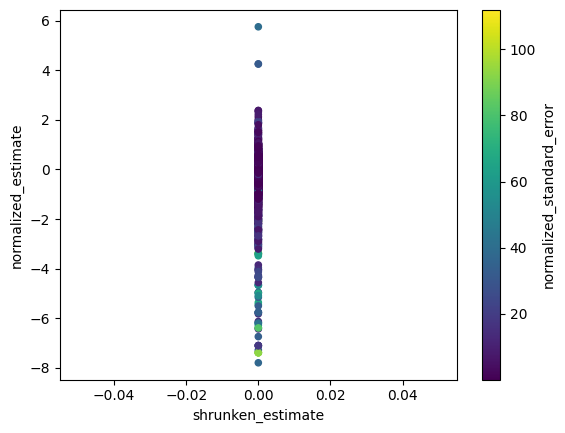

In [26]:
output.plot.scatter(
    x="shrunken_estimate",
    y="normalized_estimate",
    c="normalized_standard_error"
)

In [20]:
output["z"] = np.abs(output["shrunken_estimate"] / output["shrunken_se"])

<Axes: xlabel='shrunken_estimate', ylabel='z'>

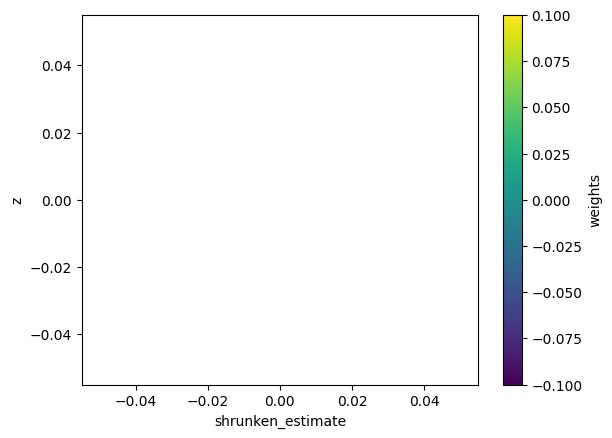

In [21]:
output.plot.scatter(x="shrunken_estimate", y="z", c="weights")

In [22]:
output.sort_values(by="z").query("z > 1").tail(50)

,weights,normalized_estimate,normalized_standard_error,shrunken_estimate,shrunken_se,z


/tmp/ipykernel_2231405/2379782205.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x=df[balanced_matrix[term].sort_values().gt(0)]["log2FoldChange"],
/tmp/ipykernel_2231405/2379782205.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  xerr=df[balanced_matrix[term].sort_values().gt(0)]["lfcSE"],
/tmp/ipykernel_2231405/2379782205.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y=df[balanced_matrix[term].sort_values().gt(0)]["lfcSE"].index,
/tmp/ipykernel_2231405/2379782205.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x=df[balanced_matrix[term].sort_values().gt(0)]["log2FoldChange"],
/tmp/ipykernel_2231405/2379782205.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y=df[balanced_matrix[term].sort_values().gt(0)]["lfcSE"].index,


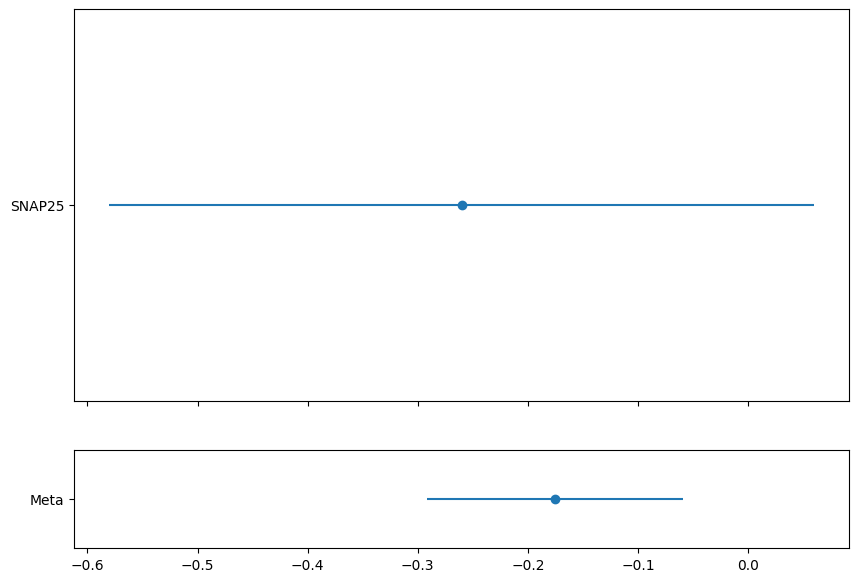

In [13]:
import matplotlib.pyplot as plt
f, ax = plt.subplots(nrows=2, figsize=(10, 7), height_ratios=[4, 1], sharex=True)
term = "Synaptic Vesicle Fusion to Presynaptic Active Zone Membrane (GO:0031629)"

df = df.loc[genes_available]
balanced_matrix = balanced_matrix.loc[genes_available]

ax[0].errorbar(
    x=df[balanced_matrix[term].sort_values().gt(0)]["log2FoldChange"],
    xerr=df[balanced_matrix[term].sort_values().gt(0)]["lfcSE"],
    y=df[balanced_matrix[term].sort_values().gt(0)]["lfcSE"].index,
    linestyle=""
)

ax[0].scatter(
    x=df[balanced_matrix[term].sort_values().gt(0)]["log2FoldChange"],
    y=df[balanced_matrix[term].sort_values().gt(0)]["lfcSE"].index,
)

ax[1].errorbar(
    x=[output.loc[term, "shrunken_estimate"]],
    xerr=[1.96 * output.loc[term, "shrunken_se"]],
    y=["Meta"]
)

ax[1].scatter(
    x=[output.loc[term, "shrunken_estimate"]],
    y=["Meta"]
)